In [1]:

import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
import os

ruta = r"C:\Users\TAWTOCA\Downloads\precipitacion_cds_atl"
archivos = [f for f in os.listdir(ruta) if f.endswith('.nc')]
print(f"Total de archivos: {len(archivos)}")
print(archivos[:5])  # muestra los primeros 5


Total de archivos: 365
['Precipitation-Flux_C3S-glob-agric_AgERA5_20170101_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Precipitation-Flux_C3S-glob-agric_AgERA5_20170102_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Precipitation-Flux_C3S-glob-agric_AgERA5_20170103_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Precipitation-Flux_C3S-glob-agric_AgERA5_20170104_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc', 'Precipitation-Flux_C3S-glob-agric_AgERA5_20170105_final-v2.0.0.area-subset.11.3.-74.5.10.2.-75.2.nc']


In [3]:
import xarray as xr

ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

print(ds)


<xarray.Dataset> Size: 118kB
Dimensions:             (time: 365, lat: 11, lon: 7)
Coordinates:
  * time                (time) datetime64[ns] 3kB 2017-01-01 ... 2017-12-31
  * lat                 (lat) float64 88B 11.2 11.1 11.0 10.9 ... 10.4 10.3 10.2
  * lon                 (lon) float64 56B -75.1 -75.0 -74.9 ... -74.6 -74.5
Data variables:
    Precipitation_Flux  (time, lat, lon) float32 112kB dask.array<chunksize=(1, 11, 7), meta=np.ndarray>
    crs                 (time) int64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    title:        AgERA5 daily weather variables derived from the ECMWF ERA5 ...
    institution:  Wageningen Environmental Research
    history:      Generated by `pragera5 run_daily_processing 2017-01-01` ver...
    references:   https://doi.org/10.24381/cds.6c68c9bb
    source:       ECWMF ERA5 reanalysis, https://doi.org/10.24381/cds.143582cf


In [3]:
print(list(ds.data_vars))  # muestra las variables disponibles

['Precipitation_Flux', 'crs']


In [4]:
ds['Precipitation_Flux']

<xarray.DataArray 'Precipitation_Flux' (time: 365, lat: 11, lon: 7)> Size: 112kB
dask.array<concatenate, shape=(365, 11, 7), dtype=float32, chunksize=(1, 11, 7), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 2017-01-01 2017-01-02 ... 2017-12-31
  * lat      (lat) float64 88B 11.2 11.1 11.0 10.9 10.8 ... 10.5 10.4 10.3 10.2
  * lon      (lon) float64 56B -75.1 -75.0 -74.9 -74.8 -74.7 -74.6 -74.5
Attributes:
    units:                 mm d-1
    grid_mapping:          crs
    long_name:             Total precipitation (00-00LT)
    temporal_aggregation:  Sum 00-00LT

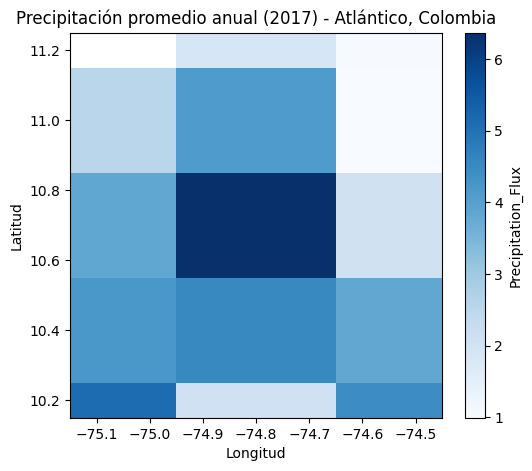

In [7]:
# Variable principal
var = ds['Precipitation_Flux']

# --- 1️⃣ Promedio anual espacial ---
promedio_anual = var.mean(dim="time")

plt.figure(figsize=(6,5))
promedio_anual.plot(cmap="Blues")
plt.title("Precipitación promedio anual (2017) - Atlántico, Colombia")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()


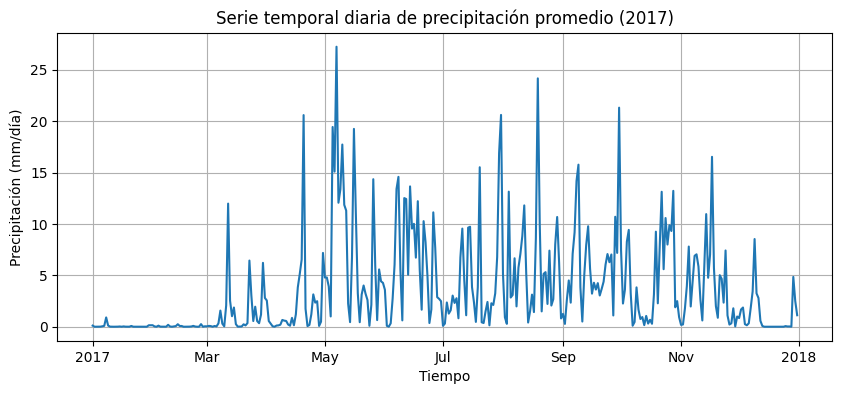

In [8]:
# --- 2️⃣ Serie temporal promedio (sobre toda el área) ---
serie_temporal = var.mean(dim=["lat", "lon"])

plt.figure(figsize=(10,4))
serie_temporal.plot()
plt.title("Serie temporal diaria de precipitación promedio (2017)")
plt.ylabel("Precipitación (mm/día)")
plt.xlabel("Tiempo")
plt.grid(True)
plt.show()

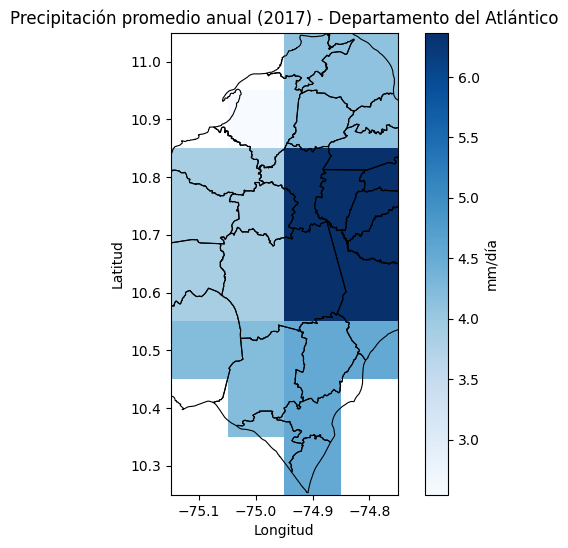

In [4]:
var = ds["Precipitation_Flux"]

# Especificar CRS (coordenadas geográficas)
var = var.rio.write_crs("EPSG:4326")

# ----------------------------------------------------------
# 2️⃣ Cargar shapefile de municipios del Atlántico
# ----------------------------------------------------------
gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'})
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

# ----------------------------------------------------------
# 3️⃣ Recortar el raster al límite del departamento
# ----------------------------------------------------------
recorte = var.rio.clip(gdf.geometry, gdf.crs)

# Promedio anual (sumar o promediar en el tiempo)
promedio_anual_atl = recorte.mean(dim="time")

# ----------------------------------------------------------
# 4️⃣ Graficar mapa final
# ----------------------------------------------------------
plt.figure(figsize=(7, 6))
promedio_anual_atl.plot(cmap="Blues", cbar_kwargs={'label': 'mm/día'})
gdf.boundary.plot(color="black", linewidth=0.8, ax=plt.gca())
plt.title("Precipitación promedio anual (2017) - Departamento del Atlántico")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

In [6]:
import os
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1️⃣ Cargar los datos NetCDF (todas las fechas del 2017)
# ------------------------------------------------------------
ruta = r"C:\Users\TAWTOCA\Downloads\precipitacion_cds_atl"
ds = xr.open_mfdataset(os.path.join(ruta, "*.nc"), combine="by_coords")

# Variable principal y CRS
var = ds["Precipitation_Flux"].rio.write_crs("EPSG:4326")

# Promedio anual
promedio_anual = var.mean(dim="time")

# ------------------------------------------------------------
# 2️⃣ Shapefile del Atlántico
# ------------------------------------------------------------
gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding="utf_8")
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'})
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

# ------------------------------------------------------------
# 3️⃣ Guardar raster temporal y calcular promedio por municipio
# ------------------------------------------------------------
temp_raster = "promedio_anual_atl.tif"
promedio_anual.rio.to_raster(temp_raster)

stats = zonal_stats(
    gdf,
    temp_raster,
    stats="mean",
    nodata=np.nan
)



<Figure size 800x700 with 0 Axes>

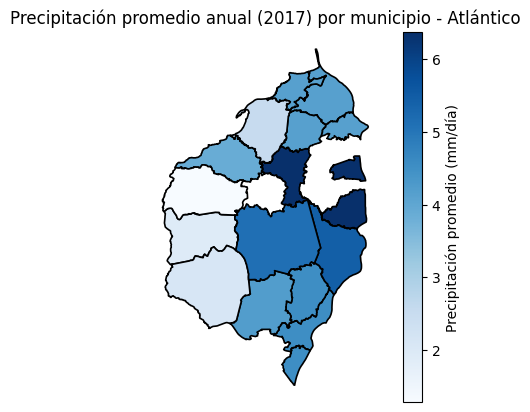

In [7]:
# ------------------------------------------------------------
# 4️⃣ Añadir resultados al GeoDataFrame
# ------------------------------------------------------------
gdf["precip_mm_dia"] = [s["mean"] for s in stats]

# ------------------------------------------------------------
# 5️⃣ Graficar mapa final
# ------------------------------------------------------------
plt.figure(figsize=(8,7))
gdf.plot(column="precip_mm_dia",
         cmap="Blues",
         legend=True,
         legend_kwds={"label": "Precipitación promedio (mm/día)"},
         edgecolor="black",
         linewidth=1.2)  # más grueso
plt.title("Precipitación promedio anual (2017) por municipio - Atlántico")
plt.axis("off")
plt.show()


# ------------------------------------------------------------
# 6️⃣ (Opcional) Exportar tabla con resultados
# ------------------------------------------------------------
gdf[["municipio", "precip_mm_dia"]].to_csv("precipitacion_municipios_atlantico_2017.csv", index=False)
